In [ ]:
# FAKE NEWS DETECTION 

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("news.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (6335, 4)

First 5 Rows:
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  

Columns:
['Unnamed: 0', 'title', 'text', 'label']

Missing Values:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [ ]:
#2. REMOVE MISSING VALUES

df = df.dropna()

print("\nShape after removing missing values:", df.shape)

# 3. COMBINE TITLE AND TEXT


if "title" in df.columns and "text" in df.columns:
    df["content"] = df["title"] + " " + df["text"]

elif "text" in df.columns:
    df["content"] = df["text"]

else:
    raise ValueError("Could not find 'text' or 'title' columns.")

# 4. CLEAN TEXT


def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["content"] = df["content"].apply(clean_text)

# 5. CONVERT LABELS

print("\nOriginal Label Values:")
print(df["label"].value_counts())

# Convert FAKE / REAL into 0 / 1
df["label"] = df["label"].astype(str).str.upper()

df["label"] = df["label"].map({
    "FAKE": 0,
    "REAL": 1
})

# Remove unknown labels if any
df = df.dropna(subset=["label"])

df["label"] = df["label"].astype(int)

print("\nFinal Label Distribution:")
print(df["label"].value_counts())



Shape after removing missing values: (6335, 4)

Original Label Values:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64

Final Label Distribution:
label
1    3171
0    3164
Name: count, dtype: int64


In [ ]:
# 6. FEATURES AND TARGET

X = df["content"]
y = df["label"]


# 7. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# 8. TF-IDF + LOGISTIC REGRESSION

lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            stop_words="english"
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])


# 9. HYPERPARAMETER TUNING

lr_params = {
    "tfidf__max_features": [20000, 30000, 50000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.1, 0.5, 1, 2, 5, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_search = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("\nTraining Tuned Logistic Regression...")

lr_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(lr_search.best_params_)

print("\nBest Cross-Validation F1:")
print(round(lr_search.best_score_, 4))


# 10. LINEAR SVM

svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            stop_words="english"
        )
    ),
    (
        "model",
        LinearSVC(
            class_weight="balanced"
        )
    )
])

svm_params = {
    "tfidf__max_features": [20000, 30000, 50000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.1, 0.5, 1, 2, 5]
}

svm_search = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("\nTraining Tuned Linear SVM...")

svm_search.fit(X_train, y_train)

print("\nBest SVM Parameters:")
print(svm_search.best_params_)

print("\nBest SVM Cross-Validation F1:")
print(round(svm_search.best_score_, 4))


Training samples: 5068
Testing samples: 1267

Training Tuned Logistic Regression...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters:
{'model__C': 10, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation F1:
0.9347

Training Tuned Linear SVM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best SVM Parameters:
{'model__C': 5, 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 2)}

Best SVM Cross-Validation F1:
0.9409



Tuned Logistic Regression
Accuracy : 0.9511
Precision: 0.9554
Recall   : 0.9464
F1 Score : 0.9509
ROC-AUC  : 0.9888

Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.96      0.95       633
        Real       0.96      0.95      0.95       634

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267


Tuned Linear SVM
Accuracy : 0.9495
Precision: 0.9495
Recall   : 0.9495
F1 Score : 0.9495
ROC-AUC  : 0.9907

Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95       633
        Real       0.95      0.95      0.95       634

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267



MODEL COMPARISON
                       Model  Accuracy  Precision  Rec

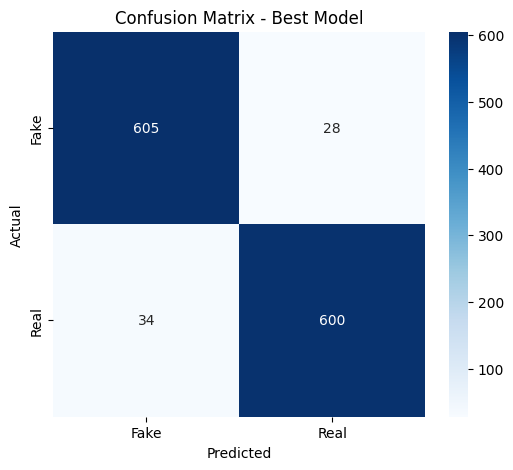


FINAL BEST MODEL RESULTS
Model: Tuned Logistic Regression
Accuracy : 95.11 %
Precision: 95.54 %
Recall   : 94.64 %
F1 Score : 95.09 %
ROC-AUC  : 98.88 %


In [ ]:
# 11. EVALUATION FUNCTION

def evaluate_model(name, model, is_svm=False):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # ROC-AUC
    if is_svm:
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(
        y_test,
        y_score
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Fake", "Real"],
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


# 12. EVALUATE MODELS

results = []

results.append(
    evaluate_model(
        "Tuned Logistic Regression",
        lr_search.best_estimator_
    )
)

results.append(
    evaluate_model(
        "Tuned Linear SVM",
        svm_search.best_estimator_,
        is_svm=True
    )
)


# 13. MODEL COMPARISON

results_df = pd.DataFrame(results)

print("\n\nMODEL COMPARISON")
print("=" * 80)

print(
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .round(4)
)


# 14. SELECT BEST MODEL

best_index = results_df["F1 Score"].idxmax()

best_model_name = results_df.loc[
    best_index,
    "Model"
]

print("\nBest Model based on F1 Score:")
print(best_model_name)


if best_model_name == "Tuned Logistic Regression":

    best_model = lr_search.best_estimator_
    is_svm = False

else:

    best_model = svm_search.best_estimator_
    is_svm = True


# 15. CONFUSION MATRIX

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Model")

plt.show()

# 16. FINAL RESULTS

best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("\nFINAL BEST MODEL RESULTS")
print("=" * 50)

print("Model:", best_model_name)

print(
    "Accuracy :",
    round(best_result["Accuracy"] * 100, 2),
    "%"
)

print(
    "Precision:",
    round(best_result["Precision"] * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(best_result["Recall"] * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(best_result["F1 Score"] * 100, 2),
    "%"
)

print(
    "ROC-AUC  :",
    round(best_result["ROC-AUC"] * 100, 2),
    "%"
)